**Это упражнение из курса [Computer Vision](https://www.kaggle.com/learn/computer-vision). Вы можете обратиться к учебнику по [этой ссылке](https://www.kaggle.com/ryanholbrook/data-augmentation).**

---

# Введение #

В этих упражнениях вы изучите, какой эффект различные случайные преобразования оказывают на изображение, подумаете, какие виды аугментации могут быть уместны для данного набора данных, а затем примените аугментацию данных к набору *Car or Truck* для обучения собственной сети.

Запустите ячейку ниже, чтобы всё настроить!

In [1]:
# Setup feedback system
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers.experimental import preprocessing

# Imports
import os, warnings
import matplotlib.pyplot as plt
from matplotlib import gridspec

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Reproducability
def set_seed(seed=31415):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    #os.environ['TF_DETERMINISTIC_OPS'] = '1'
set_seed()

# Set Matplotlib defaults
plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)
plt.rc('image', cmap='magma')
warnings.filterwarnings("ignore") # to clean up output cells


# Load training and validation sets
ds_train_ = image_dataset_from_directory(
    '/tf/Lessons/4._Computer_Vision/data/train',
    labels='inferred',
    label_mode='binary',
    image_size=[128, 128],
    interpolation='nearest',
    batch_size=64,
    shuffle=True,
)
ds_valid_ = image_dataset_from_directory(
    '/tf/Lessons/4._Computer_Vision/data/valid',
    labels='inferred',
    label_mode='binary',
    image_size=[128, 128],
    interpolation='nearest',
    batch_size=64,
    shuffle=False,
)

# Data Pipeline
def convert_to_float(image, label):
    image = tf.image.convert_image_dtype(image, dtype=tf.float32)
    return image, label

AUTOTUNE = tf.data.experimental.AUTOTUNE
ds_train = (
    ds_train_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)
ds_valid = (
    ds_valid_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)


2026-06-24 08:24:29.740734: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-24 08:24:29.797875: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-24 08:24:29.797909: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-24 08:24:29.799033: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-24 08:24:29.806503: I tensorflow/core/platform/cpu_feature_guar

Found 5117 files belonging to 2 classes.


2026-06-24 08:24:44.309939: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-24 08:24:44.344950: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-24 08:24:44.345116: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-24 08:24:44.348404: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-24 08:24:44.348533: I external/local_xla/xla/stream_executor

Found 5051 files belonging to 2 classes.


# (Необязательно) Изучение аугментации #

Раскомментируйте преобразование и запустите ячейку, чтобы увидеть, что оно делает. Вы также можете поэкспериментировать со значениями параметров, если хотите. (Параметры `factor` должны быть больше 0 и, как правило, меньше 1.) Запустите ячейку снова, если хотите получить новое случайное изображение.

2026-06-24 08:25:06.012501: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


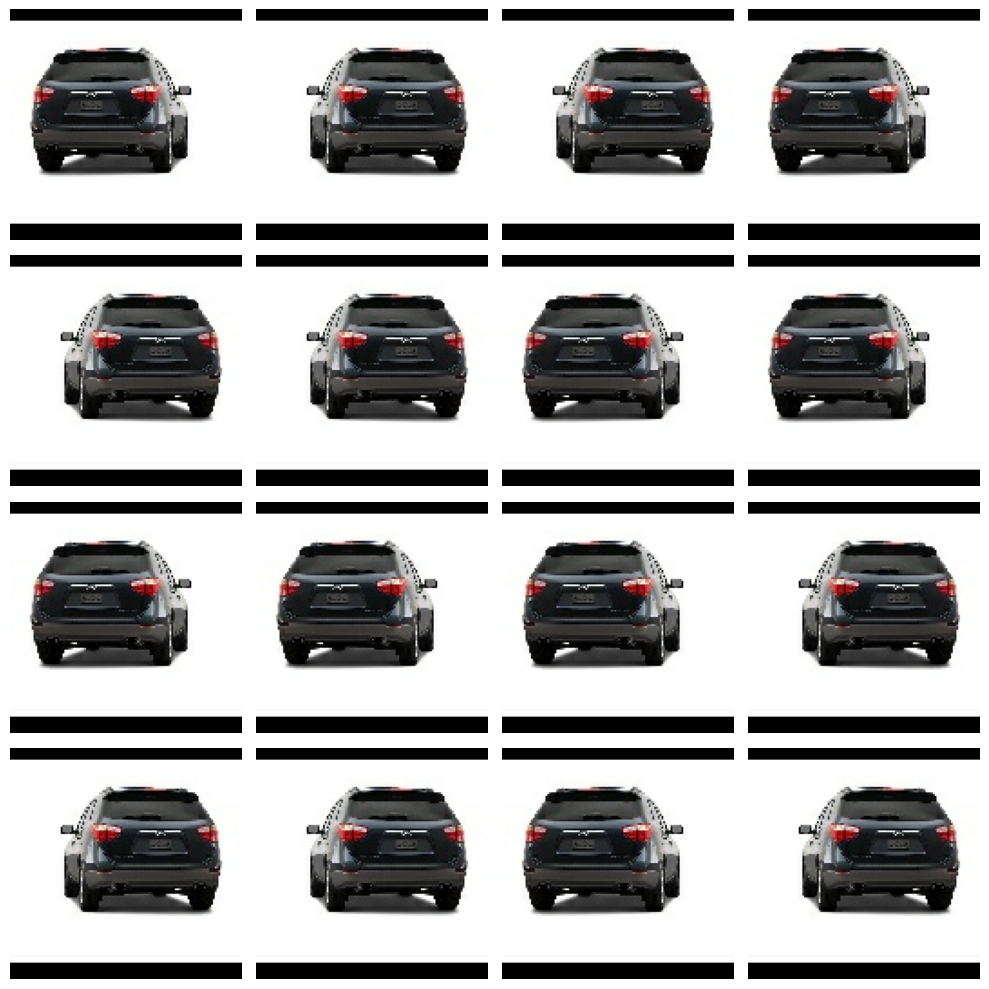

In [2]:
# all of the "factor" parameters indicate a percent-change
augment = keras.Sequential([
    # preprocessing.RandomContrast(factor=0.5),
    preprocessing.RandomFlip(mode='horizontal'), # meaning, left-to-right
    # preprocessing.RandomFlip(mode='vertical'), # meaning, top-to-bottom
    # preprocessing.RandomWidth(factor=0.15), # horizontal stretch
    # preprocessing.RandomRotation(factor=0.20),
    # preprocessing.RandomTranslation(height_factor=0.1, width_factor=0.1),
])


ex = next(iter(ds_train.unbatch().map(lambda x, y: x).batch(1)))

plt.figure(figsize=(10,10))
for i in range(16):
    image = augment(ex, training=True)
    plt.subplot(4, 4, i+1)
    plt.imshow(tf.squeeze(image))
    plt.axis('off')
plt.show()

Кажутся ли выбранные вами преобразования разумными для набора данных *Car or Truck*?

В этом упражнении мы рассмотрим несколько наборов данных и подумаем, какие виды аугментации могут быть уместны. Ваши рассуждения могут отличаться от того, что мы обсуждаем в решении. Это нормально. Смысл этих задач — просто задуматься о том, как преобразование может взаимодействовать с задачей классификации — в лучшую или худшую сторону.

Набор данных [EuroSAT](https://www.kaggle.com/ryanholbrook/eurosat) состоит из спутниковых снимков Земли, классифицированных по географическим признакам. Ниже приведены несколько изображений из этого набора данных.

<figure>
<img src="./img/LxARYZe.png" width=600, alt="Шестнадцать спутниковых снимков с подписями: SeaLake, PermanentCrop, Industrial, Pasture, Residential и Forest.">
</figure>

# 1) EuroSAT #

Какие виды преобразований могут быть уместны для этого набора данных?

Правильно:

 На мой взгляд, сначала стоит попробовать переворот и поворот на 90 градусов, поскольку для фотографий, сделанных прямо над головой, не существует понятия ориентации. Однако ни одно из этих преобразований не должно привести к путанице в классах.

Набор данных [TensorFlow Flowers](https://www.kaggle.com/ryanholbrook/tensorflow-flowers) состоит из фотографий цветов нескольких видов. Ниже приведён пример.

<figure>
<img src="./img/Mt7PR2x.png" width=600, alt="Шестнадцать изображений цветов с подписями: roses, tulips, dandelion и sunflowers">
</figure>

# 2) TensorFlow Flowers #

Какие виды преобразований могут быть уместны для набора данных TensorFlow Flowers?

Правильно:

 На мой взгляд, в первую очередь стоит попробовать горизонтальную зеркальную симметрию и умеренное вращение. Некоторые библиотеки для аугментации включают в себя изменение оттенка (например, с красного на синий). Поскольку цвет цветка, как правило, является отличительной чертой его вида, изменение оттенка может оказаться не столь эффективным. С другой стороны, среди культурных цветов, таких как розы, существует удивительное разнообразие оттенков, так что, в зависимости от набора данных, это может оказаться полезным!

Теперь вы будете использовать аугментацию данных с собственной свёрточной сетью, аналогичной той, что вы построили в Упражнении 5. Поскольку аугментация данных фактически увеличивает размер набора данных, мы можем соответственно увеличить ёмкость модели без особого риска переобучения.

# 3) Добавление слоёв предобработки #

Добавьте эти слои предобработки в данную модель.

```
preprocessing.RandomContrast(factor=0.10),
preprocessing.RandomFlip(mode='horizontal'),
preprocessing.RandomRotation(factor=0.10),
```

In [4]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.InputLayer(input_shape=[128, 128, 3]),
    
    # Data Augmentation
    preprocessing.RandomContrast(factor=0.10),
    preprocessing.RandomFlip(mode='horizontal'),
    preprocessing.RandomRotation(factor=0.10),

    # Block One
    layers.BatchNormalization(renorm=True),
    layers.Conv2D(filters=64, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPool2D(),

    # Block Two
    layers.BatchNormalization(renorm=True),
    layers.Conv2D(filters=128, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPool2D(),

    # Block Three
    layers.BatchNormalization(renorm=True),
    layers.Conv2D(filters=256, kernel_size=3, activation='relu', padding='same'),
    layers.Conv2D(filters=256, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPool2D(),

    # Head
    layers.BatchNormalization(renorm=True),
    layers.Flatten(),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid'),
])


Теперь мы обучим модель. Запустите следующую ячейку, чтобы скомпилировать её с функцией потерь и метрикой точности, а затем обучить на тренировочном наборе.

Epoch 1/50


2026-06-24 08:27:52.107778: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8906
2026-06-24 08:27:55.431291: I external/local_xla/xla/service/service.cc:168] XLA service 0x7b8a8c9632b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-06-24 08:27:55.431368: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2026-06-24 08:27:55.442005: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1782289675.548626    2349 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


80/80 [==============================] - 33s 254ms/step - loss: 0.6766 - binary_accuracy: 0.5806 - val_loss: 0.6653 - val_binary_accuracy: 0.6145
Epoch 2/50
80/80 [==============================] - 12s 153ms/step - loss: 0.6585 - binary_accuracy: 0.6099 - val_loss: 0.6586 - val_binary_accuracy: 0.6090
Epoch 3/50
80/80 [==============================] - 13s 168ms/step - loss: 0.6405 - binary_accuracy: 0.6396 - val_loss: 0.6128 - val_binary_accuracy: 0.6531
Epoch 4/50
80/80 [==============================] - 13s 165ms/step - loss: 0.5738 - binary_accuracy: 0.7100 - val_loss: 0.5443 - val_binary_accuracy: 0.7232
Epoch 5/50
80/80 [==============================] - 13s 167ms/step - loss: 0.5605 - binary_accuracy: 0.7176 - val_loss: 0.5511 - val_binary_accuracy: 0.7228
Epoch 6/50
80/80 [==============================] - 13s 163ms/step - loss: 0.5251 - binary_accuracy: 0.7403 - val_loss: 0.5251 - val_binary_accuracy: 0.7412
Epoch 7/50
80/80 [==============================] - 13s 166ms/step - 

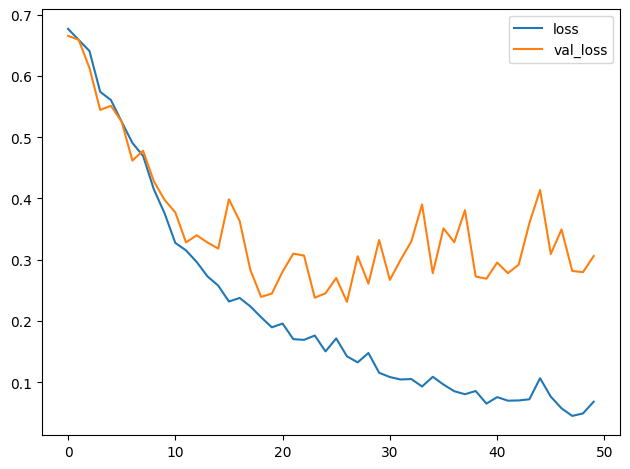

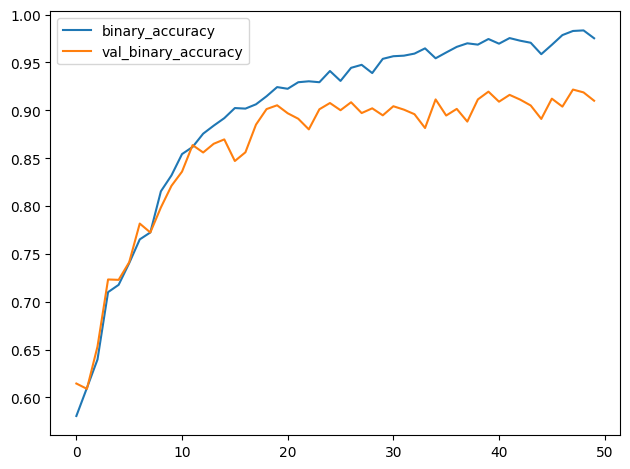

In [5]:
optimizer = tf.keras.optimizers.Adam(epsilon=0.01)
model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['binary_accuracy'],
)

history = model.fit(
    ds_train,
    validation_data=ds_valid,
    epochs=50,
)

# Plot learning curves
import pandas as pd
history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['binary_accuracy', 'val_binary_accuracy']].plot();

# 4) Обучение модели #

Изучите кривые обучения. Есть ли признаки переобучения? Как производительность этой модели соотносится с другими моделями, которые вы обучали в этом курсе?

Решение: кривые обучения в этой модели оставались близкими друг к другу гораздо дольше, чем в предыдущих моделях. Это говорит о том, что аугментация помогла предотвратить переобучение, позволив модели продолжать совершенствоваться. 

 Обратите внимание, что эта модель показала самую высокую точность среди всех моделей, представленных в курсе! Так бывает не всегда, но это показывает, что хорошо спроектированная пользовательская сверточная нейронная сеть иногда может работать не хуже, а то и лучше, чем гораздо более крупная предварительно обученная модель. В зависимости от сферы применения, использование модели меньшего размера (требующей меньше ресурсов) может стать большим преимуществом.

# Заключение #

Аугментация данных — это мощный и часто используемый инструмент для улучшения обучения моделей, не только свёрточных сетей, но и многих других типов нейросетевых моделей. Каким бы ни была ваша задача, принцип остаётся тем же: вы можете компенсировать недостаток данных, добавив «синтетические» данные, чтобы его восполнить. Эксперименты с аугментациями — отличный способ узнать, насколько далеко могут зайти ваши данные!

# Конец #

Это всё по курсу **Computer Vision** на Kaggle Learn! Готовы применить свои знания? Ознакомьтесь с нашими двумя бонусными уроками! Они проведут вас через подготовку решения для соревнования, пока вы будете учиться обучать нейронные сети с помощью TPU — самого продвинутого ускорителя Kaggle. В конце у вас будет готовый блокнот, который можно будет дополнить собственными идеями.

- [Создайте своё первое решение](https://www.kaggle.com/ryanholbrook/create-your-first-submission) — Подготовьте решение для нашего соревнования *Petals to the Metal* Getting Started. Вы обучите нейронную сеть распознавать более 100 видов цветов.
- [Соревнование по настройке TPU](https://www.kaggle.com/ryanholbrook/tpu-hyperparameter-optimization) — Настройте гиперпараметры модели, чтобы получить максимальную производительность от TPU.

---



*Остались вопросы или комментарии? Посетите [форум обсуждения курса](https://www.kaggle.com/learn/computer-vision/discussion), чтобы пообщаться с другими учащимися.*